# Assignment: Exploratory Data Analysis

**Q1.** In class, we talked about how to compute the sample mean of a variable $X$,
$$
m(X) = \dfrac{1}{N} \sum_{i=1}^N x_i
$$
and sample covariance of two variables $X$ and $Y$,
$$
\text{cov}(X,Y) = \dfrac{1}{N} \sum_{i=1}^N (x_i - m(X))(y_i - m(Y))).
$$
Recall, the sample variance of $X$ is
$$
s^2 = \dfrac{1}{N} \sum_{i=1}^N (x_i - m(X))^2.
$$
It can be very helpful to understand some basic properties of these statistics. If you want to write your calculations on a piece of paper, take a photo, and upload that to your GitHub repo, that's probably easiest.

1. Show that $m(a + bX) = a+b \times m(X)$.
2. Show that $\text{cov}(X,a+bY) = b \times \text{cov}(X,Y)$
3. Show that $\text{cov}(a+bX,a+bX) = b^2 \text{cov}(X,X) $, and in particular that $\text{cov}(X,X) = s^2 $.
4. Consider a non-decreasing transformation $g()$. Is is always true that $m(g(X))= g(m(X))$?

**Q2.** This question looks at financial transfers from foreign entities to American universities. In particular, from which countries and giftors are the gifts coming from, and to which institutions are they going? For this question, `.groupby([vars]).count()` and `.groupby([vars]).sum()` will be especially useful to tally the number of occurrences and sum the values of those occurrences.

1. Load the `./data/ForeignGifts_edu.csv` dataset.
2. For `Foreign Gift Amount`, create a histogram and describe the variable. Describe your findings.
3. For `Gift Type`, create a histogram or value counts table. What proportion of the gifts are contracts, real estate, and monetary gifts?
4. Create a kernel density plot of the log of `Foreign Gift Amount`, and then a kernel density plot of the log of `Foreign Gift Amount` conditional on gift type. Do you notice any patterns?
5. What are the top 15 countries in terms of the number of gifts? What are the top 15 countries in terms of the amount given?
6. Which giftors provide the most money, in total?

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** [To be provided]

**Date:** [To be provided]

(28221, 10)
<class 'pandas.DataFrame'>
RangeIndex: 28221 entries, 0 to 28220
Data columns (total 10 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   ID                          28221 non-null  int64
 1   OPEID                       28221 non-null  int64
 2   Institution Name            28221 non-null  str  
 3   City                        28221 non-null  str  
 4   State                       28221 non-null  str  
 5   Foreign Gift Received Date  28221 non-null  int64
 6   Foreign Gift Amount         28221 non-null  int64
 7   Gift Type                   28221 non-null  str  
 8   Country of Giftor           28221 non-null  str  
 9   Giftor Name                 24470 non-null  str  
dtypes: int64(4), str(6)
memory usage: 2.2 MB
ID                               0
OPEID                            0
Institution Name                 0
City                             0
State                            0
Foreign G

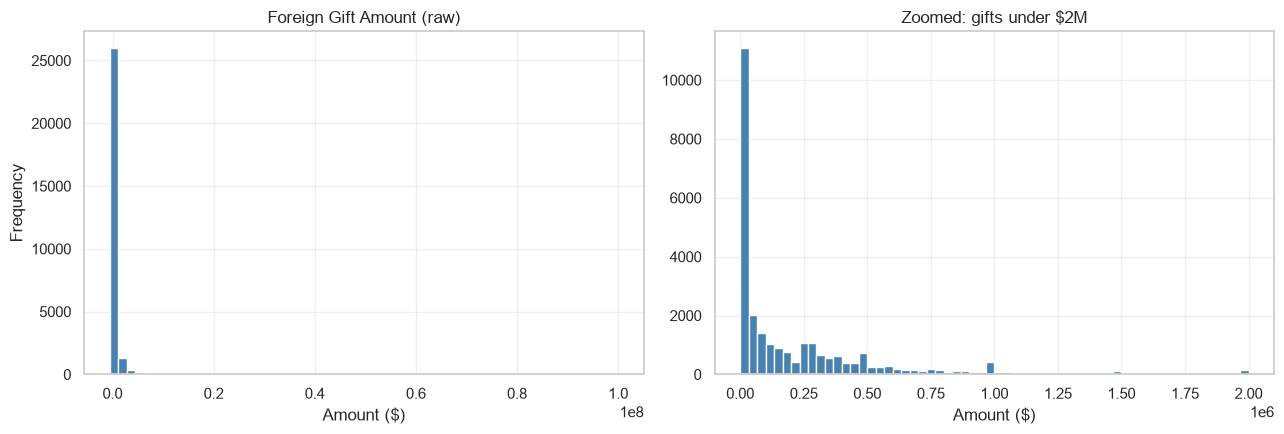

Non-positive records: 24


,count,proportion (%)
Gift Type,,
Contract,17274,61.21
Monetary Gift,10936,38.75
Real Estate,11,0.04


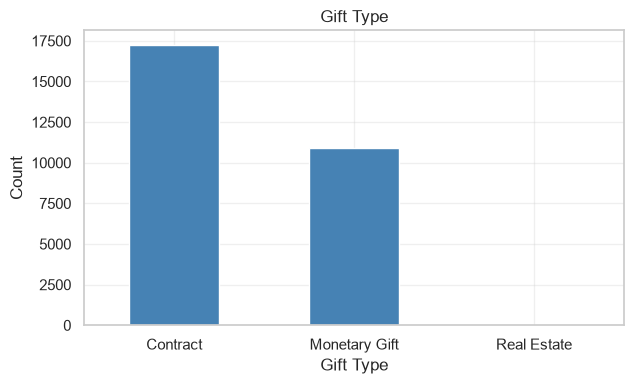

Dropped 24 non-positive records before logging


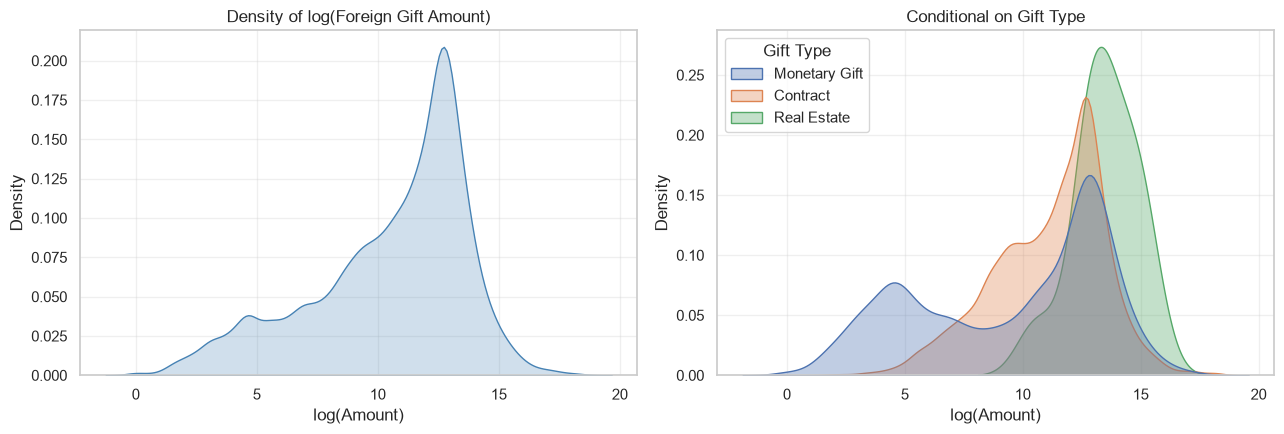

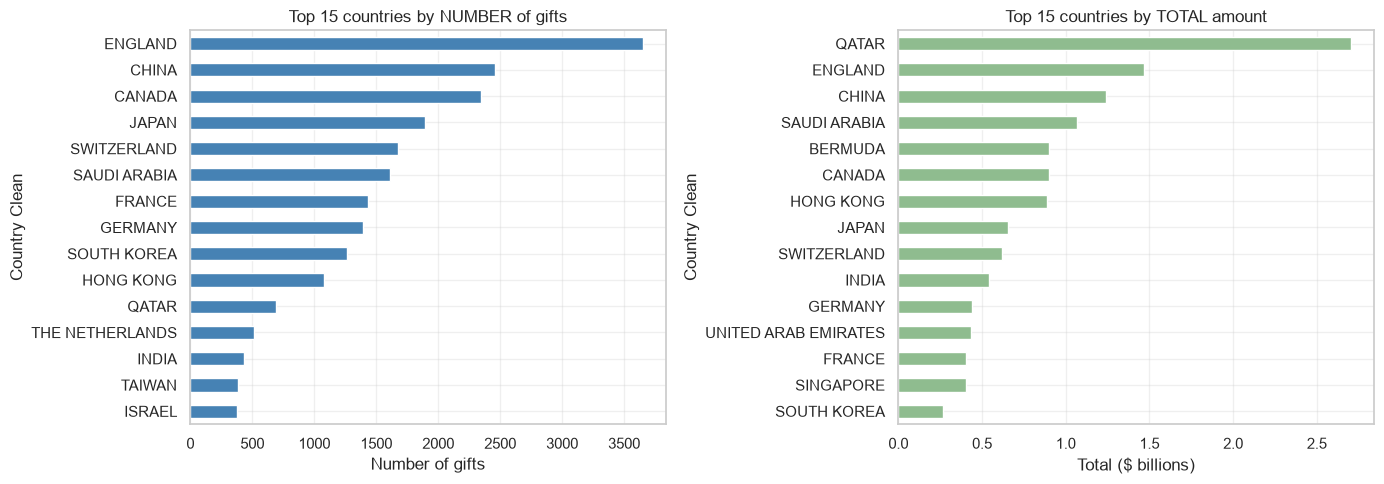

,total,n_gifts,avg_gift
Giftor Name,,,
Qatar Foundation,1166503744,261,"4,469,363.00"
Qatar Foundation/Qatar National Res,796197000,10,"79,619,700.00"
Qatar Foundation for Education,373945215,6,"62,324,202.50"
Anonymous,338793629,262,"1,293,105.45"
Saudi Arabian Cultural Mission,275221475,480,"573,378.07"
HCL,190000000,5,"38,000,000.00"
Church of Jesus Christ of LDS,185203715,7,"26,457,673.57"
Emirates Institute for Advanced Sc,170641244,24,"7,110,051.83"
QIC,148355497,2,"74,177,748.50"


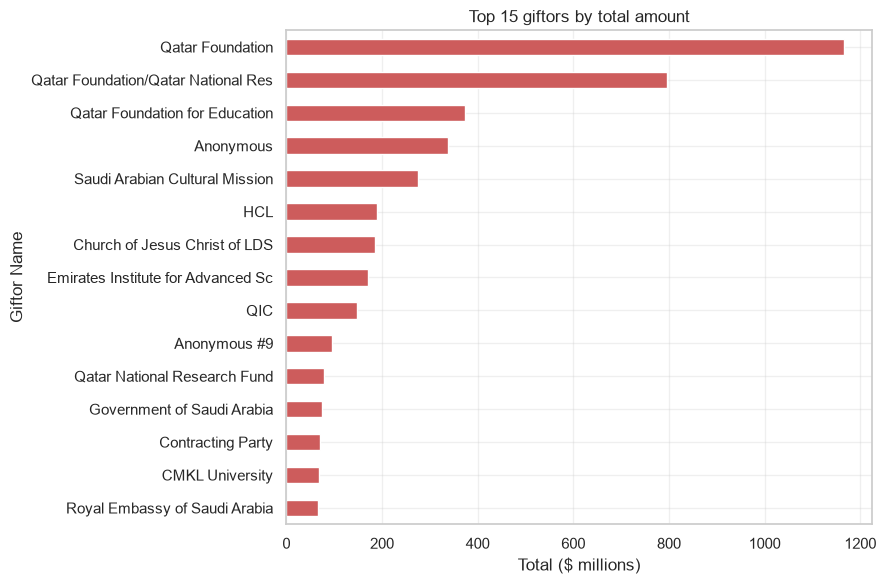

All Qatar-named giftors: $2.49B across 609 records
Grand total:             $16.60B
Qatar share:             15.0%


Giftor Name
Qatar Foundation                       261
Qatar National Research Fund           124
Qatar National Research Foundation      89
Qatar University                        17
Qatar Research Foundation               17
Qatar Petroleum                         10
Embassy of the State of Qatar           10
Qatar Foundation/Qatar National Res     10
Qatar Foundation for Education           6
Qatar National Research                  6
Name: count, dtype: int64

In [10]:
# Your Phase 1 solution to the problem goes here.
#Question 1: I have written this in Latex using overleaf. I will upload the pdf to my folder and push it.
#Question 2:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

df = pd.read_csv('./data/ForeignGifts_edu.csv')
print(df.shape)
df.head()

df.info()
print(df.isna().sum())
df['Foreign Gift Amount'].describe()

#2.2
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].hist(df['Foreign Gift Amount'], bins=60, color='steelblue', edgecolor='white')
axes[0].set_title('Foreign Gift Amount (raw)')
axes[0].set_xlabel('Amount ($)')
axes[0].set_ylabel('Frequency')

sub = df[df['Foreign Gift Amount'].between(0, 2_000_000)]
axes[1].hist(sub['Foreign Gift Amount'], bins=60, color='steelblue', edgecolor='white')
axes[1].set_title('Zoomed: gifts under $2M')
axes[1].set_xlabel('Amount ($)')

plt.tight_layout()
plt.show()

print("Non-positive records:", (df['Foreign Gift Amount'] <= 0).sum())

#2.3
counts = df['Gift Type'].value_counts()
props  = df['Gift Type'].value_counts(normalize=True)

display(pd.DataFrame({'count': counts, 'proportion (%)': (props * 100).round(2)}))

ax = counts.plot(kind='bar', color='steelblue', figsize=(6.5, 4), rot=0)
ax.set_title('Gift Type')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()
#2.4
pos = df[df['Foreign Gift Amount'] > 0].copy()
pos['log_amount'] = np.log(pos['Foreign Gift Amount'])
print(f"Dropped {len(df) - len(pos)} non-positive records before logging")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.kdeplot(data=pos, x='log_amount', fill=True, ax=axes[0], color='steelblue')
axes[0].set_title('Density of log(Foreign Gift Amount)')
axes[0].set_xlabel('log(Amount)')

sns.kdeplot(data=pos, x='log_amount', hue='Gift Type',
            fill=True, alpha=0.35, common_norm=False, ax=axes[1])
axes[1].set_title('Conditional on Gift Type')
axes[1].set_xlabel('log(Amount)')

plt.tight_layout()
plt.show()

pos.groupby('Gift Type')['log_amount'].describe().round(2)
#2.5
# KOREA and SOUTH KOREA are separate labels in the raw data; collapse them
df['Country Clean'] = df['Country of Giftor'].replace({'KOREA': 'SOUTH KOREA'})

by_count = (df.groupby('Country Clean')['Foreign Gift Amount']
              .count().sort_values(ascending=False).head(15))

by_sum   = (df.groupby('Country Clean')['Foreign Gift Amount']
              .sum().sort_values(ascending=False).head(15))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

by_count.sort_values().plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Top 15 countries by NUMBER of gifts')
axes[0].set_xlabel('Number of gifts')

(by_sum.sort_values() / 1e9).plot(kind='barh', ax=axes[1], color='darkseagreen')
axes[1].set_title('Top 15 countries by TOTAL amount')
axes[1].set_xlabel('Total ($ billions)')

plt.tight_layout()
plt.show()

comp = pd.DataFrame({
    'rank_by_count': by_count.rank(ascending=False).astype(int),
    'n_gifts': by_count,
}).join(pd.DataFrame({
    'rank_by_amount': by_sum.rank(ascending=False).astype(int),
    'total_$B': (by_sum / 1e9).round(2),
}), how='outer')

comp.sort_values('rank_by_amount')

#2.6
by_giftor = (df.groupby('Giftor Name')['Foreign Gift Amount']
               .agg(total='sum', n_gifts='count')
               .sort_values('total', ascending=False)
               .head(15))
by_giftor['avg_gift'] = by_giftor['total'] / by_giftor['n_gifts']

display(by_giftor)

(by_giftor['total'].sort_values() / 1e6).plot(kind='barh', figsize=(9, 6), color='indianred')
plt.title('Top 15 giftors by total amount')
plt.xlabel('Total ($ millions)')
plt.tight_layout()
plt.show()

qatar = df['Giftor Name'].fillna('').str.contains('Qatar', case=False)
total = df['Foreign Gift Amount'].sum()

print(f"All Qatar-named giftors: ${df.loc[qatar, 'Foreign Gift Amount'].sum()/1e9:.2f}B "
      f"across {qatar.sum()} records")
print(f"Grand total:             ${total/1e9:.2f}B")
print(f"Qatar share:             {df.loc[qatar,'Foreign Gift Amount'].sum()/total*100:.1f}%")

# The variant spellings driving the fragmentation
df.loc[qatar, 'Giftor Name'].value_counts().head(10)




In [11]:
#Q2.2: Foreign Gift Amount is severely right-skewed, with a mean of $588,233 against a median of $94,615, a minimum of -$537,770 across 24 non-positive records, and a maximum of $99,999,999 that looks like a reporting cap.

#Q2.3: Contracts make up 61.21% of gifts (17,274), monetary gifts 38.75% (10,936), and real estate 0.04% (11), meaning most of this money is commercial rather than philanthropic.

#Q2.4: Monetary gifts are clearly bimodal with a second mode near log 4.5 (about $90) and are far more dispersed than contracts (sd 4.02 vs 2.39), because contracts have a practical floor on size that donations do not.

#Q2.5: England leads by number of gifts (3,655) while Qatar leads by amount ($2.71B) despite ranking only 11th by count, and Bermuda, the UAE, and Singapore appear in the amount top-15 without appearing in the count top-15 at all.

#Q2.6: The Qatar Foundation provides the most money, and because Giftor Name is truncated at about 34 characters it is split across several variants that together total $2.49B, or 15.0% of the $16.60B overall.

## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** cbf37aff79161fca8c014ce682e5db4cb70914dd
- **AI tool and model used:** Chat GPT 5.6 Sol


### *Prompts used

1. What are some improvements I can add to my existing code using these sets of data?
2. Is there anything else that will help produce the most clean output?

### *AI-proposed changes


[Paste the AI's concise numbered list verbatim.]
1. Validate the required columns and convert Foreign Gift Amount to numeric before analysis.
2. Report missing values, especially the 3,751 missing giftor names.
3. Replace the arbitrary $2 million histogram cutoff with the dataset’s 99th percentile.
4. Add written findings explaining the amount distribution, including its strong right skew and 24 non-positive values.
5. Label the Gift Type bar chart and report the exact proportions for all three categories.
6. Exclude non-positive amounts only from the log analysis and explain why they were excluded.
7. Standardize country labels by trimming whitespace, converting to uppercase, and combining KOREA with SOUTH KOREA.
8. Consider combining every giftor name containing “Qatar” into one giftor category.
9. Report the number and total value of records with missing giftor names before ranking named giftors.
10. Use separate top-15 tables for country gift counts, country gift totals, and giftor

### *Evaluation of AI suggestions


| Change | Decision | Reason and verification                                                                                                                                 |
| ------ | -------- | ------------------------------------------------------------------------------------------------------------------------------------------------------- |
| 1      | Accept   | The dataset contains all required columns, and numeric conversion preserved all 28,221 gift amounts.                                                    |
| 2      | Accept   | The missing-value check found 3,751 missing giftor names and no missing values in the other required columns.                                           |
| 3      | Accept   | The 99th percentile is about $7.57 million, providing a data-based histogram cutoff that retains 99% of the records.                                    |
| 4      | Accept   | The mean is about $588,233, while the median is $94,615, confirming that the gift amounts are strongly right-skewed.                                    |
| 5      | Accept   | The verified proportions are 61.21% Contract, 38.75% Monetary Gift, and 0.04% Real Estate.                                                              |
| 6      | Accept   | The 24 non-positive amounts must be excluded from the log analysis because their logarithms are undefined.                                              |
| 7      | Accept   | The data contains 452 `KOREA` records and 811 `SOUTH KOREA` records, so combining these labels prevents the same country from being counted separately. |
| 8      | Reject   | Qatar-related names may represent different organizations, so combining all of them could create a misleading giftor ranking.                           |
| 9      | Accept   | The 3,751 missing giftor names account for about $4.80 billion, making it important to disclose their exclusion from the named-giftor ranking.          |
| 10     | Accept   | Separate top-15 tables clearly answer the questions about gift frequency, country totals, and giftor totals.                                            |


### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

Dataset shape: (28221, 10)

Missing values:
Foreign Gift Amount       0
Gift Type                 0
Country of Giftor         0
Giftor Name            3751
dtype: int64

Data types:
<class 'pandas.DataFrame'>
RangeIndex: 28221 entries, 0 to 28220
Data columns (total 10 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   ID                          28221 non-null  int64
 1   OPEID                       28221 non-null  int64
 2   Institution Name            28221 non-null  str  
 3   City                        28221 non-null  str  
 4   State                       28221 non-null  str  
 5   Foreign Gift Received Date  28221 non-null  int64
 6   Foreign Gift Amount         28221 non-null  int64
 7   Gift Type                   28221 non-null  str  
 8   Country of Giftor           28221 non-null  str  
 9   Giftor Name                 24470 non-null  str  
dtypes: int64(4), str(6)
memory usage: 2.2 MB

Foreign Gift 

,Foreign Gift Amount
count,"28,221.00"
mean,"588,232.72"
std,"3,222,011.43"
min,"-537,770.00"
25%,"5,700.00"
50%,"94,615.00"
75%,"376,142.00"
90%,"983,954.00"
95%,"1,875,000.00"
99%,"7,568,696.20"


Non-positive gift amounts: 24
99th-percentile amount: $7,568,696.20


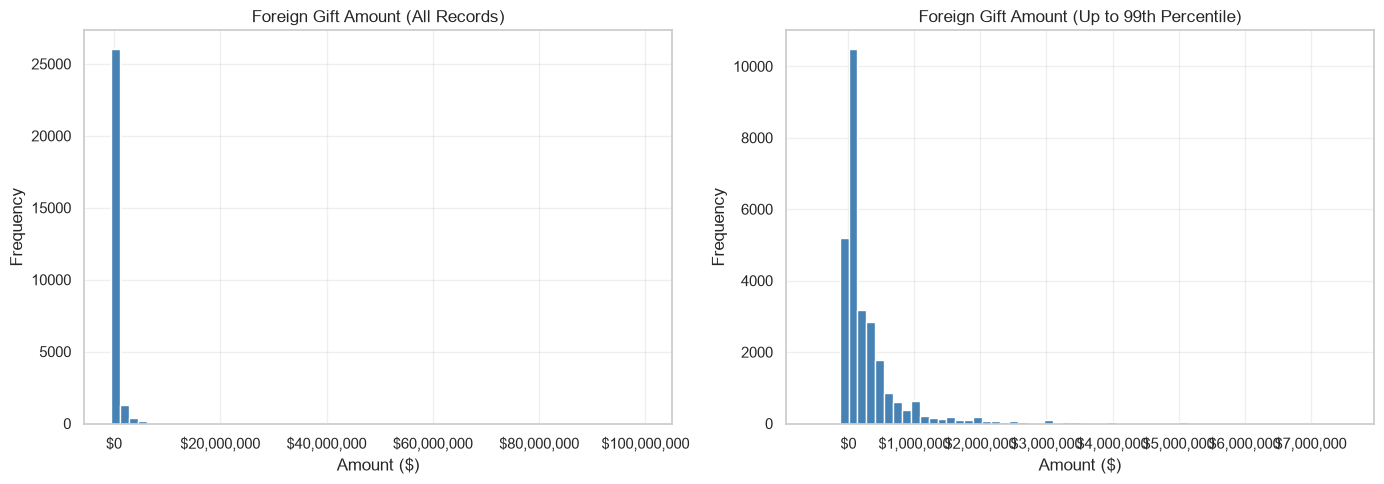


Finding: Foreign gift amounts are strongly right-skewed. The mean is $588,233, compared with a median of $94,615. The maximum is $99,999,999, and there are 24 non-positive records.


,Count,Proportion (%)
Gift Type,,
Contract,17274,61.21
Monetary Gift,10936,38.75
Real Estate,11,0.04


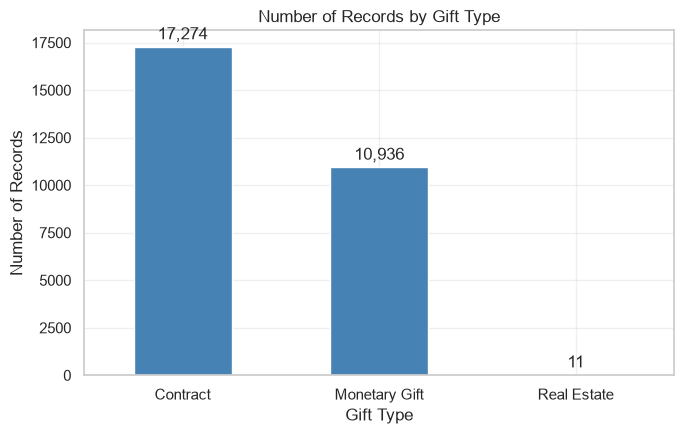

Finding: Contracts represent 61.21% of the records, monetary gifts represent 38.75%, and real estate represents only 0.04%.
Excluded 24 non-positive records because the natural log is undefined for zero and negative values.


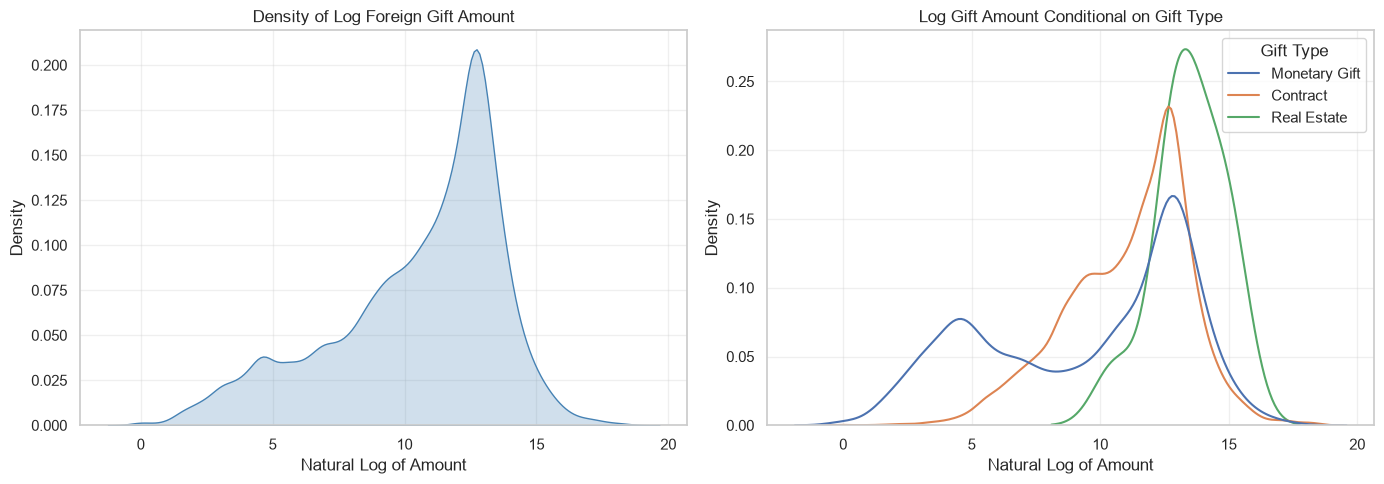

,count,mean,median,std,min,max
Gift Type,,,,,,
Contract,17250,11.12,11.61,2.39,0.00,18.42
Monetary Gift,10936,9.55,10.82,4.02,0.00,17.70
Real Estate,11,13.48,13.41,1.34,10.58,15.28


Finding: Contracts generally have higher logged amounts than monetary gifts. Real estate has the highest median logged amount, but there are only 11 real-estate records, so that pattern should be interpreted cautiously.
Top 15 countries by number of gifts:


,n_gifts,total_$B
Country Clean,,
ENGLAND,3655,1.46
CHINA,2461,1.24
CANADA,2344,0.90
JAPAN,1896,0.66
SWITZERLAND,1676,0.62
SAUDI ARABIA,1610,1.07
FRANCE,1437,0.41
GERMANY,1394,0.44
SOUTH KOREA,1263,0.27


Top 15 countries by total amount:


,n_gifts,total_$B
Country Clean,,
QATAR,693,2.71
ENGLAND,3655,1.46
CHINA,2461,1.24
SAUDI ARABIA,1610,1.07
BERMUDA,117,0.90
CANADA,2344,0.90
HONG KONG,1080,0.89
JAPAN,1896,0.66
SWITZERLAND,1676,0.62


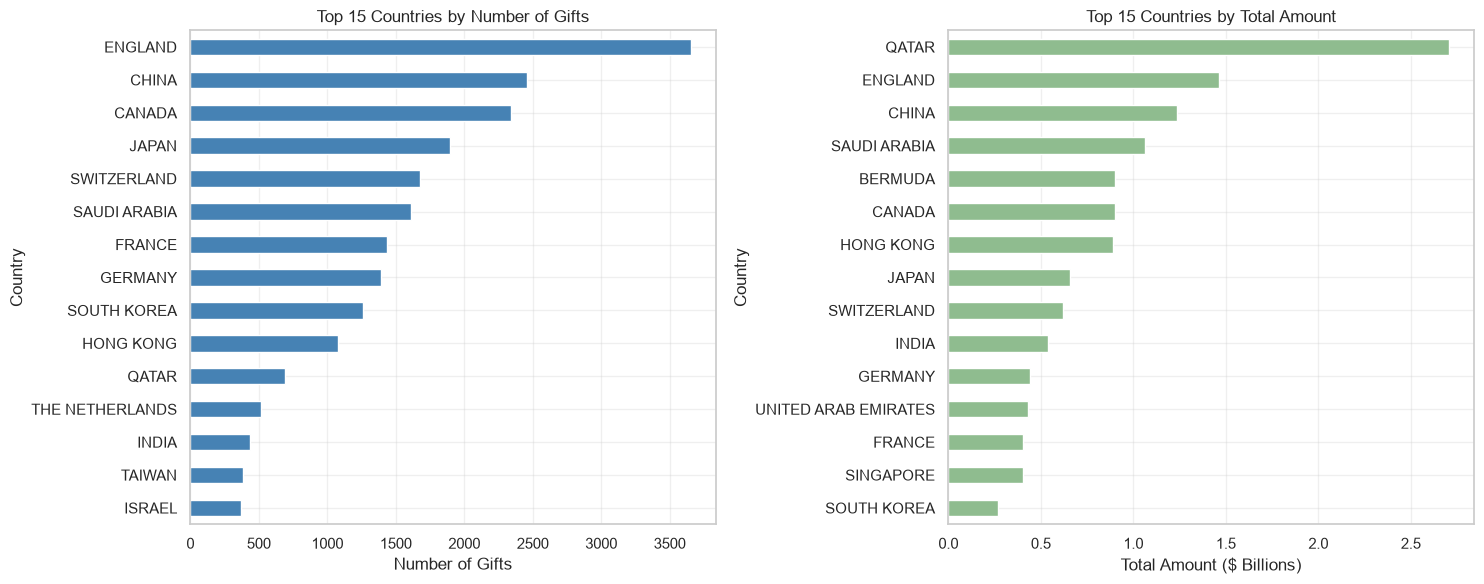

Finding: England has the largest number of records, while Qatar has the highest total amount. This shows that receiving more gifts does not necessarily mean receiving the most money.
Records with missing giftor names: 3,751
Amount linked to missing giftor names: $4,799,900,945

Top 15 named giftors by total amount:


,n_gifts,total_$M,average_gift
Giftor Clean,,,
Qatar Foundation,261,"1,166.50","4,469,363.00"
Qatar Foundation/Qatar National Res,10,796.20,"79,619,700.00"
Qatar Foundation for Education,6,373.95,"62,324,202.50"
Anonymous,262,338.79,"1,293,105.45"
Saudi Arabian Cultural Mission,480,275.22,"573,378.07"
HCL,5,190.00,"38,000,000.00"
Church of Jesus Christ of LDS,7,185.20,"26,457,673.57"
Emirates Institute for Advanced Sc,24,170.64,"7,110,051.83"
QIC,2,148.36,"74,177,748.50"


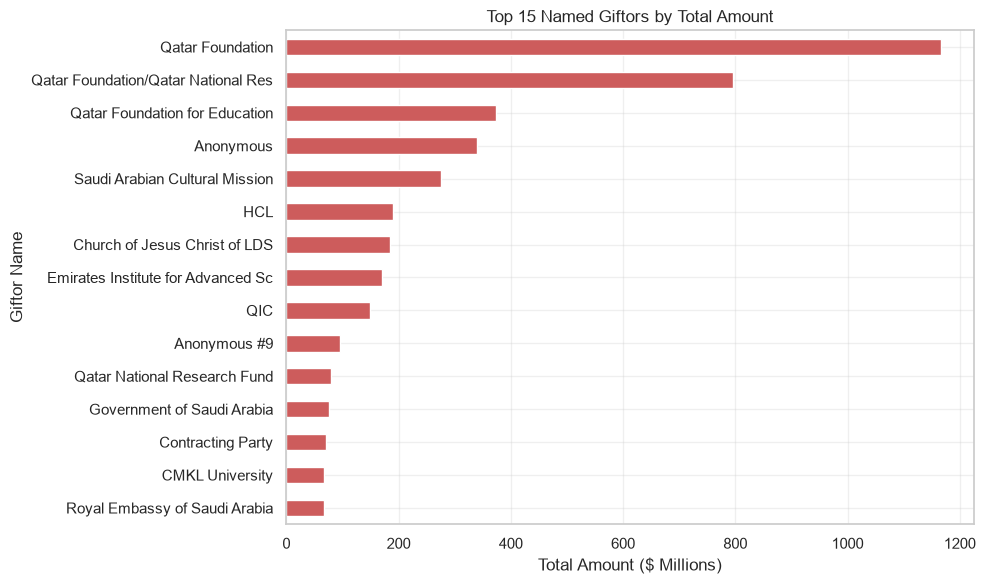

Finding: Qatar Foundation is the highest-ranked exact giftor name. However, several separate Qatar-related names appear in the data. They were not combined because they may represent different organizations.


In [12]:
# Your Phase 2 solution to the problem goes here.
# If seaborn is not already installed, run this once:
# %pip install seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import StrMethodFormatter

sns.set_theme(style="whitegrid")
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

# Question 2.1: Load and inspect the data
df = pd.read_csv("./data/ForeignGifts_edu.csv")

required_columns = [
    "Foreign Gift Amount",
    "Gift Type",
    "Country of Giftor",
    "Giftor Name"
]

assert set(required_columns).issubset(df.columns), "Required columns are missing."

df["Foreign Gift Amount"] = pd.to_numeric(
    df["Foreign Gift Amount"], errors="coerce"
)

print("Dataset shape:", df.shape)
print("\nMissing values:")
print(df[required_columns].isna().sum())

print("\nData types:")
df.info()


# Question 2.2: Analyze Foreign Gift Amount
amount_summary = df["Foreign Gift Amount"].describe(
    percentiles=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
)

print("\nForeign Gift Amount summary:")
display(amount_summary.to_frame())

nonpositive = (df["Foreign Gift Amount"] <= 0).sum()
zoom_max = df["Foreign Gift Amount"].quantile(0.99)

print(f"Non-positive gift amounts: {nonpositive}")
print(f"99th-percentile amount: ${zoom_max:,.2f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(
    df["Foreign Gift Amount"].dropna(),
    bins=60,
    color="steelblue",
    edgecolor="white"
)
axes[0].set_title("Foreign Gift Amount (All Records)")
axes[0].set_xlabel("Amount ($)")
axes[0].set_ylabel("Frequency")
axes[0].xaxis.set_major_formatter(StrMethodFormatter("${x:,.0f}"))

zoomed = df[df["Foreign Gift Amount"] <= zoom_max]

axes[1].hist(
    zoomed["Foreign Gift Amount"].dropna(),
    bins=60,
    color="steelblue",
    edgecolor="white"
)
axes[1].set_title("Foreign Gift Amount (Up to 99th Percentile)")
axes[1].set_xlabel("Amount ($)")
axes[1].set_ylabel("Frequency")
axes[1].xaxis.set_major_formatter(StrMethodFormatter("${x:,.0f}"))

plt.tight_layout()
plt.show()

print(
    "\nFinding: Foreign gift amounts are strongly right-skewed. "
    f"The mean is ${df['Foreign Gift Amount'].mean():,.0f}, compared with "
    f"a median of ${df['Foreign Gift Amount'].median():,.0f}. The maximum "
    f"is ${df['Foreign Gift Amount'].max():,.0f}, and there are "
    f"{nonpositive} non-positive records."
)


# Question 2.3: Analyze Gift Type
gift_counts = df["Gift Type"].value_counts()
gift_proportions = (
    df["Gift Type"].value_counts(normalize=True).mul(100)
)

gift_type_summary = pd.DataFrame({
    "Count": gift_counts,
    "Proportion (%)": gift_proportions.round(2)
})

display(gift_type_summary)

ax = gift_counts.plot(
    kind="bar",
    color="steelblue",
    figsize=(7, 4.5),
    rot=0
)

ax.set_title("Number of Records by Gift Type")
ax.set_xlabel("Gift Type")
ax.set_ylabel("Number of Records")
ax.bar_label(ax.containers[0], fmt="{:,.0f}", padding=3)

plt.tight_layout()
plt.show()

print(
    "Finding: Contracts represent 61.21% of the records, monetary gifts "
    "represent 38.75%, and real estate represents only 0.04%."
)


# Question 2.4: Log gift amount distributions
positive = df[df["Foreign Gift Amount"] > 0].copy()
positive["log_amount"] = np.log(positive["Foreign Gift Amount"])

dropped = len(df) - len(positive)

print(
    f"Excluded {dropped} non-positive records because the natural log "
    "is undefined for zero and negative values."
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.kdeplot(
    data=positive,
    x="log_amount",
    fill=True,
    color="steelblue",
    ax=axes[0]
)
axes[0].set_title("Density of Log Foreign Gift Amount")
axes[0].set_xlabel("Natural Log of Amount")
axes[0].set_ylabel("Density")

sns.kdeplot(
    data=positive,
    x="log_amount",
    hue="Gift Type",
    common_norm=False,
    ax=axes[1]
)
axes[1].set_title("Log Gift Amount Conditional on Gift Type")
axes[1].set_xlabel("Natural Log of Amount")
axes[1].set_ylabel("Density")

plt.tight_layout()
plt.show()

log_summary = (
    positive.groupby("Gift Type")["log_amount"]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .round(2)
)

display(log_summary)

print(
    "Finding: Contracts generally have higher logged amounts than monetary "
    "gifts. Real estate has the highest median logged amount, but there are "
    "only 11 real-estate records, so that pattern should be interpreted cautiously."
)


# Question 2.5: Top countries by count and total amount
df["Country Clean"] = (
    df["Country of Giftor"]
    .astype("string")
    .str.strip()
    .str.upper()
    .replace({"KOREA": "SOUTH KOREA"})
)

country_summary = (
    df.groupby("Country Clean", dropna=False)["Foreign Gift Amount"]
    .agg(n_gifts="count", total_amount="sum")
)

top_countries_count = country_summary.nlargest(15, "n_gifts").copy()
top_countries_amount = country_summary.nlargest(15, "total_amount").copy()

top_countries_count["total_$B"] = (
    top_countries_count["total_amount"] / 1e9
).round(2)

top_countries_amount["total_$B"] = (
    top_countries_amount["total_amount"] / 1e9
).round(2)

print("Top 15 countries by number of gifts:")
display(top_countries_count[["n_gifts", "total_$B"]])

print("Top 15 countries by total amount:")
display(top_countries_amount[["n_gifts", "total_$B"]])

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

top_countries_count["n_gifts"].sort_values().plot(
    kind="barh",
    ax=axes[0],
    color="steelblue"
)
axes[0].set_title("Top 15 Countries by Number of Gifts")
axes[0].set_xlabel("Number of Gifts")
axes[0].set_ylabel("Country")

(top_countries_amount["total_amount"].sort_values() / 1e9).plot(
    kind="barh",
    ax=axes[1],
    color="darkseagreen"
)
axes[1].set_title("Top 15 Countries by Total Amount")
axes[1].set_xlabel("Total Amount ($ Billions)")
axes[1].set_ylabel("Country")

plt.tight_layout()
plt.show()

print(
    "Finding: England has the largest number of records, while Qatar has "
    "the highest total amount. This shows that receiving more gifts does "
    "not necessarily mean receiving the most money."
)


# Question 2.6: Giftors providing the most money
df["Giftor Clean"] = (
    df["Giftor Name"]
    .astype("string")
    .str.strip()
    .str.replace(r"\s+", " ", regex=True)
)

missing_giftor = df["Giftor Clean"].isna()
missing_count = missing_giftor.sum()
missing_total = df.loc[
    missing_giftor, "Foreign Gift Amount"
].sum()

print(f"Records with missing giftor names: {missing_count:,}")
print(f"Amount linked to missing giftor names: ${missing_total:,.0f}")

giftor_summary = (
    df.dropna(subset=["Giftor Clean"])
    .groupby("Giftor Clean")["Foreign Gift Amount"]
    .agg(total_amount="sum", n_gifts="count")
)

giftor_summary["average_gift"] = (
    giftor_summary["total_amount"] /
    giftor_summary["n_gifts"]
)

top_giftors = giftor_summary.nlargest(15, "total_amount").copy()
top_giftors["total_$M"] = (
    top_giftors["total_amount"] / 1e6
).round(2)

print("\nTop 15 named giftors by total amount:")
display(top_giftors[["n_gifts", "total_$M", "average_gift"]])

(top_giftors["total_amount"].sort_values() / 1e6).plot(
    kind="barh",
    figsize=(10, 6),
    color="indianred"
)

plt.title("Top 15 Named Giftors by Total Amount")
plt.xlabel("Total Amount ($ Millions)")
plt.ylabel("Giftor Name")
plt.tight_layout()
plt.show()

print(
    "Finding: Qatar Foundation is the highest-ranked exact giftor name. "
    "However, several separate Qatar-related names appear in the data. "
    "They were not combined because they may represent different organizations."
)


In [13]:
# 2.1: The dataset contains 28,221 records and 10 variables describing foreign gifts to American universities.

# 2.2: Foreign gift amounts are strongly right-skewed, with a median of $94,615, a mean of $588,233, and a maximum of nearly $100 million.

# 2.3: Contracts account for 61.21% of records, monetary gifts account for 38.75%, and real estate accounts for 0.04%.

# 2.4: After excluding 24 non-positive amounts, contracts generally have larger logged amounts than monetary gifts, while the real-estate group is too small to support a strong conclusion.

# 2.5: England has the highest number of gifts, while Qatar has the highest total amount, so gift frequency and total value produce different country rankings.

# 2.6: Qatar Foundation is the largest named giftor by total amount, although 3,751 records worth about $4.80 billion have missing giftor names.

### *Reflection on AI assistance
In your own words without generative AI.

[In 150–300 words, describe the main improvements, AI mistakes or limitations, how the final solution was verified, and any remaining concerns.]

The revised code improves my original solution by validating the required columns, handling missing values more clearly, and answering each question more directly. For the gift amount analysis, it replaces the arbitrary $2 million histogram cutoff with the 99th percentile and adds a written explanation of the strong right skew. For the log analysis, it removes only the 24 non-positive amounts because their logarithms are undefined, while keeping those records in the other analyses. It also reports the exact proportions for each gift type and standardizes country names by combining KOREA and SOUTH KOREA. One limitation in the AI suggestions was the idea of combining every giftor name containing “Qatar.” I rejected this because names such as Qatar Foundation and Qatar National Research Fund may represent different organizations, and merging them could create a misleading ranking. The results showed that contracts make up 61.21% of records, England has the most gifts, and Qatar has the highest total amount. Remaining concerns include 3,751 missing giftor names representing about $4.80 billion, inconsistent giftor spellings, and the very small number of real-estate records.